### Final Project - Online Shoppers Purchasing Intention Dataset

Dataset main page: [here](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)

Dataset zip file: [here](https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip)


The dataset is from the *UCI Machine Learning Repository*. The data models user behavior on a popular e-commerce site to predict the intent to make a purchase.

Note: The feature metrics relate to user behavior, such as time on a page, page type visited, time of year (special events), and bounce and exit rates.

**Objective:**
- The question we are trying to solve is: **will a session result in a purchase?**
- This matters because it can reveal which parts of the user journey are associated with friction, such as high bounce and exit behavior or weak product engagement.
- The broader goal is not only to compare models, but also to interpret what the strongest signals suggest about shopper behavior.

**Dataset Details:**

- Contains feature vectors from 12,300 user sessions.
- Each session belongs to a different user over a 1 year period, which helps to avoid focusing to heavily user profiles that frequent the sight often.
- The target variable is `Revenue`, which is binary (`True` or `False`), making this a supervised classification problem.
- `Weekend` and `Revenue` are converted into numeric binary values during cleaning.

- Several categorical features are converted using **one-hot encoding**:
    - `Month`
    - `OperatingSystems`
    - `Browser`
    - `Region`
    - `TrafficType`
    - `VisitorType`

- The continuous features are scaled only for the logistic regression model, where its important to normalize the feature to prevent distortion in the model. The tree based models use the encoded values without scaling, as tree models split data on thresholds not coefficient size.

- `PageValues` is excluded from the main workflow because it is too closely tied to conversion and would leak target information into the prediction task.  This report will include an shorter analysis that incorporates PageValues for comparison purposes.

**Model Selection:**

_Logistic Regression_ is used as a baseline model because it fits this binary classification model well, it is designed to predict outcomes with two possible choices, in this case: sessions that purchase, or do not purchase.

_Decision Trees_  is used here as they are a good fit for modeling data sets that have many categorical features as in naturally builds rule based spilts.  The visual tree diagram is also very useful to interpret what the rules were based on.

_Random Forest_ extends the tree approach by averaging across many trees.  The idea here is that this average will improves stability and class separation even if it is less interpretable than a single tree.

**Planned Modeling Workflow:**

Logistic regression uses scaled inputs and filters out the high VIF features to reduce multicollinearity.  The decision tree and random forest keep the full encoded feature set as tree based models are less sensitive to multicollinearity.

Will will use a simple stratified k-fold check before feature selection to test whether the models behave consistently across repeated splits. However, the main model comparison is based on the initial 80/20 data split.

**Data Exploration**
The exploratory graphs help describe how the data is structured and how purchasing behavior varies across time and visitor type. These charts are not meant to prove or predict outcomes, rather they provide context how the models may interpret the data, overall.

**Feature Selection**

Variance Inflation Factor (VIF) is used to check for multicollinearity in logistic regression feature set (after encoding). High VIF features are removed only for the logistic regression model, while the tree based models retain the full feature set for comparison (also encoded).

**Evaluation**

Model performance is evaluated using confusion matrices, accuracy, precision, recall, F1-score, and ROC-AUC. Because purchases are much less common than non purchases, there is more of an emphasis on purchase class recall and F1-score than on accuracy alone.

##### Setup imports 

In [171]:
# setup standard imports for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import statsmodels.api as sm

# modeling and evaluation
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree


##### Step 1 - Data Cleaning

We can see our data is in good shape, with no missing values per column and a typical split on revenue across the data set at about 15% purchase and 85% no purchase. We also remove `PageValues` during cleaning because it is too directly tied to conversion and would leak target information into the models.

In [172]:
# set data as a global variable so it can be used in other cells
data_path = "online-shoppers-intention.csv"
df = pd.read_csv(data_path)
target_column = "Revenue"

# make a working copy and convert boolean style values into numeric form to match the other columns and make it easier to work with
working_df = df.copy()
working_df["Weekend"] = working_df["Weekend"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})
working_df["Revenue"] = working_df["Revenue"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})

# remove duplicate rows and the PageValues column since it's a target leakage feature
duplicate_rows = working_df.duplicated().sum()
working_df = working_df.drop_duplicates().reset_index(drop=True)
working_df = working_df.drop(columns=["PageValues"])
clean_df = working_df.copy()

print("missing values by column:")
print(working_df.isna().sum())

print("duplicate rows removed:", duplicate_rows)
print("\n")
print(f"total rows: {working_df.shape[0]}")
print("\n")
print(f"total columns: {working_df.shape[1]}")
print("\n")
print("class balance:")
print(working_df[target_column].value_counts(normalize=True).rename("proportion"))


missing values by column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64
duplicate rows removed: 125


total rows: 12205


total columns: 17


class balance:
Revenue
0    0.843671
1    0.156329
Name: proportion, dtype: float64


#### Step 1 - Exploratory Data Analysis

Prove 3 visualizations to help understand how the data is distributed

1. Purchase Rate by Month: Helps to identify seasonal patterns in the purchase decision.  As expected, purchase rates rise as we approach the holiday season.


2. Purchase vs Non Purchase: We ran the 'class balance' above, though a visualization is easier to interpret.  It does highlight the low purchase rate, and the fact the model has less of a signal to learn from - for the purchase class.  This inbalance leads us to rely on the confusion matrix and the F1 score, recall and precision. These metrics are more important than only looking at the accuracy.  


3. Purchase Rate by Visitor Type: My intuition here would tell me that return visitors are more likely to purchase, however that is not the case as new visitors were the class that had the highest rate.


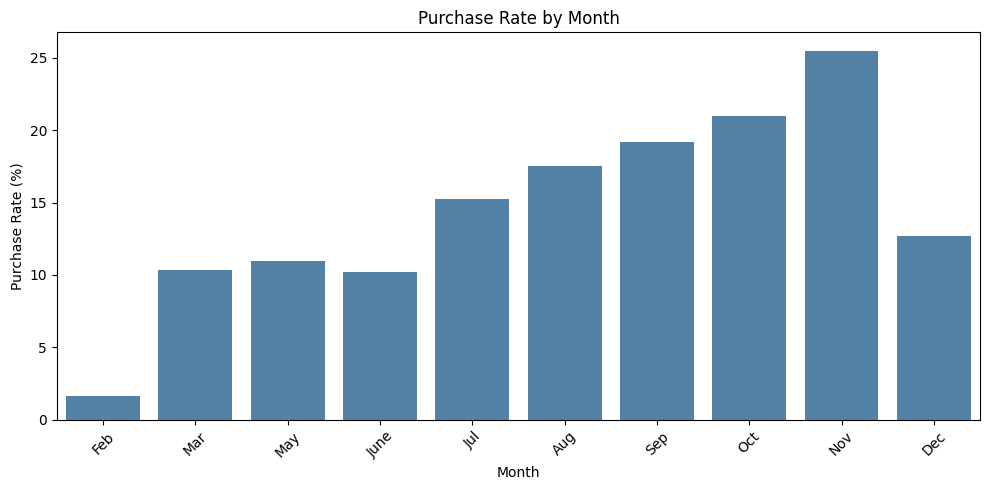

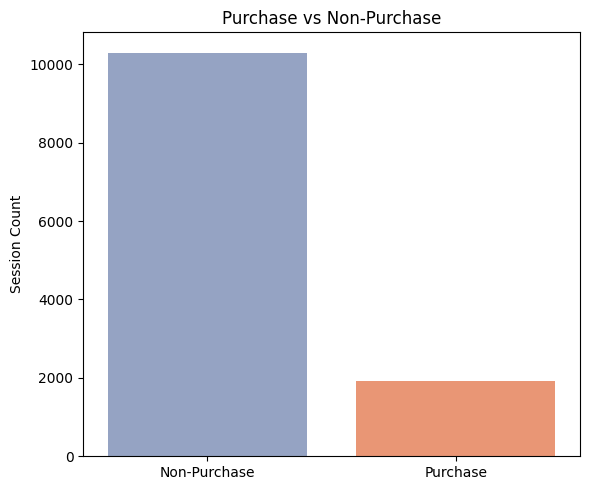

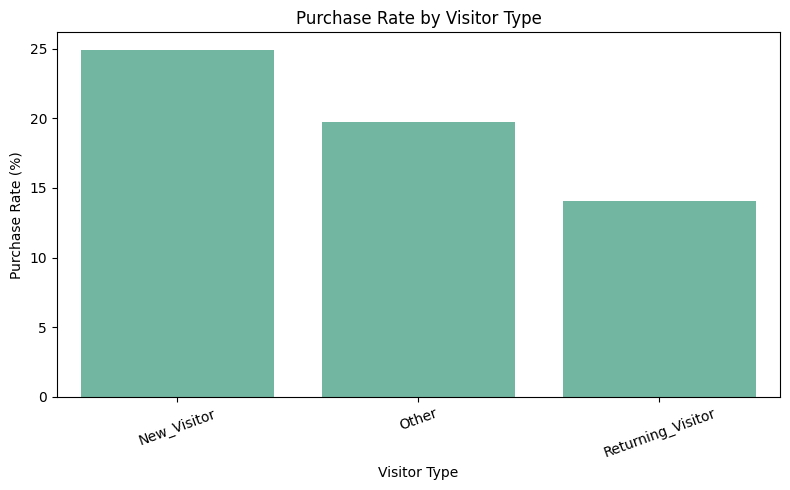

In [173]:
# Purchase Rate by Month
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "June",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

# orders by month_order
# drop any months that don't have data
# create values as a percentage on the fly
month_purchase_rate = (
    clean_df.groupby("Month")["Revenue"]
    .mean()
    .reindex(month_order)
    .dropna()
    .mul(100)
    .reset_index(name="PurchaseRate")
)

plt.figure(figsize=(10, 5))
sns.barplot(data=month_purchase_rate, x="Month", y="PurchaseRate", color="steelblue")
plt.title("Purchase Rate by Month")
plt.xlabel("Month")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Purchase vs Non Purchase
purchase_labels = clean_df["Revenue"].map({0: "Non-Purchase", 1: "Purchase"})
purchase_counts = purchase_labels.value_counts().reindex(["Non-Purchase", "Purchase"]).reset_index()
purchase_counts.columns = ["Outcome", "Count"]

plt.figure(figsize=(6, 5))
sns.barplot(
    data=purchase_counts,
    x="Outcome",
    y="Count",
    hue="Outcome",
    palette=["#8da0cb", "#fc8d62"],
    dodge=False,
    legend=False,
 )
plt.title("Purchase vs Non-Purchase")
plt.xlabel("")
plt.ylabel("Session Count")
plt.tight_layout()
plt.show()

# Purchase Rate by Visitor Type
visitor_purchase_rate = (
    clean_df.groupby("VisitorType")["Revenue"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="PurchaseRate")
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=visitor_purchase_rate,
    x="VisitorType",
    y="PurchaseRate",
    color="#66c2a5",
 )
plt.title("Purchase Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##### Step 2 - One Hot Encode Data

One hot encode the categorical values: (_Month, OperatingSystems, Browser, Region, TrafficType, and VisitorType_)

After dropping `PageValues` and using `drop_first=True`, our column count goes from 17 to 68 after one hot encoding.

The `drop_first=True` keeps one baseline category out of each dummy variable group, which is especially helpful for the logistic regression and VIF analysis.

A snippet of the first 5 rows of the data is shown with all columns, including the one-hot encoded ones.

In [174]:
# one hot encode categorical columns
working_df = clean_df.copy()

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
]

columns_to_encode = [
    column for column in categorical_features if column in working_df.columns
]

if columns_to_encode:
    working_df = pd.get_dummies(
        working_df,
        columns=columns_to_encode,
        drop_first=True,
        dtype=int,
    )

encoded_df = working_df.copy()

print(f"encoded shape: {encoded_df.shape}")
with pd.option_context("display.max_columns", None):
    display(encoded_df.head())

encoded shape: (12205, 68)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8,Browser_2,Browser_3,Browser_4,Browser_5,Browser_6,Browser_7,Browser_8,Browser_9,Browser_10,Browser_11,Browser_12,Browser_13,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,TrafficType_2,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


##### Step 3a - Normalize numeric features

For the Logistic Regression model, it's important to normalize (scale) the numeric features to prevent distortion in the model.

In [175]:
numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "SpecialDay",
    "Weekend",
]

target = "Revenue"
y = encoded_df[target].copy()
X_selected = encoded_df.drop(columns=[target]).copy()
X_tree = X_selected.copy()
X_logistic = X_selected.copy()

scaler = StandardScaler()
X_logistic[numeric_features] = scaler.fit_transform(X_logistic[numeric_features])

print(f"X_tree shape: {X_tree.shape}")
print(f"X_logistic shape: {X_logistic.shape}")
print(f"y shape: {y.shape}")
X_logistic[numeric_features].head()

X_tree shape: (12205, 67)
X_logistic shape: (12205, 67)
y shape: (12205,)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,Weekend
0,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.31024,-0.553088
1,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.595451,-0.450137,1.268054,-0.31024,-0.553088
2,-0.702302,-0.460019,-0.398824,-0.246257,-0.696218,-0.628793,3.969402,3.434394,-0.31024,-0.553088
3,-0.702302,-0.460019,-0.398824,-0.246257,-0.673793,-0.627404,0.654748,2.134590,-0.31024,-0.553088
4,-0.702302,-0.460019,-0.398824,-0.246257,-0.494387,-0.301889,-0.008183,0.184884,-0.31024,1.808031


##### Step 3b - K-Fold Validation

Using the already encoded data (and scaled data for the logistic regression model), we run a simple stratified k-fold validation before feature selection. Then we compare how the three model families perform across repeated train/validation splits instead of relying on only one split. The same folds are used for all three models to keep the comparison fair.

See section below 'Incorporating K-Fold Model Evaluation' on interpreting the K-Fold validation results.

In [176]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# set up k-fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kfold_results = []

# perform k-fold cross-validation for each model and collect results
for fold_number, (train_index, test_index) in enumerate(kfold.split(X_tree, y), start=1):
    X_logistic_train_fold = X_logistic.iloc[train_index]
    X_logistic_test_fold = X_logistic.iloc[test_index]
    X_tree_train_fold = X_tree.iloc[train_index]
    X_tree_test_fold = X_tree.iloc[test_index]
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    # train and predict with logistic regression
    logistic_fold_model = LogisticRegression(max_iter=1000, random_state=42)
    # fit the model on the training fold and predict on the test fold
    logistic_fold_model.fit(X_logistic_train_fold, y_train_fold)
    logistic_fold_pred = logistic_fold_model.predict(X_logistic_test_fold)

    # train and predict with decision tree model
    tree_fold_model = DecisionTreeClassifier(random_state=42)
    # fit the model on the training fold and predict on the test fold
    tree_fold_model.fit(X_tree_train_fold, y_train_fold)
    tree_fold_pred = tree_fold_model.predict(X_tree_test_fold)

    # train and predict with random forest model
    forest_fold_model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    )
    # fit the model on the training fold and predict on the test fold
    forest_fold_model.fit(X_tree_train_fold, y_train_fold)
    forest_fold_pred = forest_fold_model.predict(X_tree_test_fold)

    # collect results for this fold and model
    fold_predictions = [
        ("Logistic Regression", logistic_fold_pred),
        ("Decision Tree", tree_fold_pred),
        ("Random Forest", forest_fold_pred),
    ]

    # calculate metrics for each model and store results
    for model_name, predictions in fold_predictions:
        kfold_results.append(
            {
                "fold": fold_number,
                "model": model_name,
                "accuracy": accuracy_score(y_test_fold, predictions),
                "precision": precision_score(y_test_fold, predictions, zero_division=0),
                "recall": recall_score(y_test_fold, predictions, zero_division=0),
                "f1": classification_report(
                    y_test_fold,
                    predictions,
                    output_dict=True,
                    zero_division=0,
                )["1"]["f1-score"],
            }
        )

# convert results to a DataFrame and calculate summary statistics
kfold_results_df = pd.DataFrame(kfold_results)
kfold_summary = (
    kfold_results_df.groupby("model")[["accuracy", "precision", "recall", "f1"]]
    .agg(["mean", "std"])
    .round(4)
)

display(kfold_results_df)
display(kfold_summary)

,fold,model,accuracy,precision,recall,f1
0,1,Logistic Regression,0.843507,0.481481,0.034121,0.063725
1,1,Decision Tree,0.770586,0.275689,0.288714,0.282051
2,1,Random Forest,0.843916,0.500000,0.086614,0.147651
3,2,Logistic Regression,0.845555,0.571429,0.041995,0.078240
4,2,Decision Tree,0.771405,0.288783,0.317585,0.302500
5,2,Random Forest,0.849652,0.634615,0.086614,0.152425
6,3,Logistic Regression,0.844736,0.565217,0.034031,0.064198
7,3,Decision Tree,0.777550,0.302211,0.321990,0.311787
8,3,Random Forest,0.847194,0.595745,0.073298,0.130536
9,4,Logistic Regression,0.836542,0.270270,0.026178,0.047733


accuracy         precision          recall          \
                        mean     std      mean     std    mean     std   
model                                                                    
Decision Tree         0.7723  0.0060    0.2859  0.0194  0.3050  0.0233   
Logistic Regression   0.8420  0.0038    0.4303  0.1535  0.0299  0.0109   
Random Forest         0.8442  0.0045    0.5222  0.0945  0.0786  0.0075   

                         f1          
                       mean     std  
model                                
Decision Tree        0.2951  0.0211  
Logistic Regression  0.0558  0.0203  
Random Forest        0.1364  0.0134

##### Step 4a - Feature Selection

Using the VIF score, we can remove features that may lead to multicollinearity. This matters most for logistic regression.  The `drop_first=True` property helped reduce the number of features flagged with a high VIF, prior adding in that property, we had 65 features flagged and now we have 8, which is much more reasonable.

We want to use as many features as possible for a decent prediction model, but don't want to skew the logistic regression model too much by taking out a high number of features.

In [177]:

# standard threshold for VIF 
vif_threshold = 5.0
vif_input = X_logistic.astype(float).copy()

# suppress divide by zero warnings since we will be checking for infinite VIF values in the next step
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="divide by zero encountered in scalar divide",
        category=RuntimeWarning,
    )
    # calculate VIF for each feature and store results in a DataFrame
    vif_scores = pd.DataFrame(
        {
            "feature": vif_input.columns,
            "VIF": [
                variance_inflation_factor(vif_input.values, index)
                for index in range(vif_input.shape[1])
            ],
        }
    ).sort_values("VIF", ascending=False).reset_index(drop=True)

# identify features with VIF above the threshold or infinite VIF
high_vif_features = vif_scores[
    (vif_scores["VIF"] >= vif_threshold) | np.isinf(vif_scores["VIF"])
] .copy()

print(f"features with VIF >= {vif_threshold}: {len(high_vif_features)}")
display(high_vif_features)

features with VIF >= 5.0: 9


,feature,VIF
0,Browser_11,inf
1,OperatingSystems_5,inf
2,Browser_2,19.976593
3,OperatingSystems_2,16.661382
4,VisitorType_Returning_Visitor,7.243393
5,OperatingSystems_3,7.118245
6,ExitRates,6.440576
7,BounceRates,5.793424
8,Month_May,5.120574


##### Step 4b - Feature Selection Filter

We keep all encoded predictors for the decision tree and random forest and remove only the target column from that feature matrix. We remove the high- IF features only from the logistic regression feature matrix, where multicollinearity matters most.

After filtering the logistic-regression inputs, we rescale the remaining numeric features.

In [178]:
# drop high-VIF features from only the logistic regression feature set
features_to_drop = high_vif_features["feature"].tolist()

# prepare final feature sets for modeling after VIF based drop
y = encoded_df[target].copy()
full_feature_columns = [column for column in encoded_df.columns if column != target]

# tree-based models keep the full encoded feature set
X_tree = encoded_df[full_feature_columns].copy()

# logistic regression drops the high VIF columns
X_logistic = encoded_df.drop(
    columns=[target] + features_to_drop,
    errors="ignore",
).copy()
X_selected = X_logistic.copy()

# identify which numeric features remain after the VIF-based drop to re-scale only those for logistic regression
remaining_numeric_features = [
    feature for feature in numeric_features if feature in X_logistic.columns
]

# re-scale the remaining numeric features for logistic regression after the VIF-based drop
scaler = StandardScaler()
X_logistic[remaining_numeric_features] = scaler.fit_transform(
    X_logistic[remaining_numeric_features]
 )

print(f"full encoded features for tree-based models: {len(full_feature_columns)}")
print(f"dropped features for logistic regression: {len(features_to_drop)}")
print(features_to_drop)
print(f"X_tree shape with full encoded features: {X_tree.shape}")
print(f"X_logistic shape after VIF drop: {X_logistic.shape}")

full encoded features for tree-based models: 67
dropped features for logistic regression: 9
['Browser_11', 'OperatingSystems_5', 'Browser_2', 'OperatingSystems_2', 'VisitorType_Returning_Visitor', 'OperatingSystems_3', 'ExitRates', 'BounceRates', 'Month_May']
X_tree shape with full encoded features: (12205, 67)
X_logistic shape after VIF drop: (12205, 58)


##### Step 4c - Split data and model analysis 

We use the same 80% training and 20% testing row split for all models. Logistic regression uses the VIF reduced feature set, while the decision tree and random forest use the full encoded feature set.

In [179]:
# use stratified sampling to ensure the same class balance in train and test sets since the target is imbalanced
# we'll use the same train test split for both logistic regression and tree based models to ensure a fair comparison
X_logistic_train, X_logistic_test, X_tree_train, X_tree_test, y_train, y_test = train_test_split(
    X_logistic,
    X_tree,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
 )



##### Step 5a - Logistic Regression

In [180]:
# train and evaluate the logistic regression model using the VIF-reduced feature set
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_logistic_train, y_train)

# predict on the test set and evaluate metrics
y_logistic_pred = logistic_model.predict(X_logistic_test)

# calculate metrics for the logistic regression model
logistic_accuracy = accuracy_score(y_test, y_logistic_pred)
logistic_precision = precision_score(y_test, y_logistic_pred)
logistic_recall = recall_score(y_test, y_logistic_pred)
logistic_confusion = confusion_matrix(y_test, y_logistic_pred)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Logistic Regression Precision: {logistic_precision:.4f}")
print(f"Logistic Regression Recall: {logistic_recall:.4f}")
print("Logistic Regression Confusion Matrix:")
print(logistic_confusion)
print("\nClassification Report:")
print(classification_report(y_test, y_logistic_pred))

Logistic Regression Accuracy: 0.8423
Logistic Regression Precision: 0.4444
Logistic Regression Recall: 0.0314
Logistic Regression Confusion Matrix:
[[2044   15]
 [ 370   12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91      2059
           1       0.44      0.03      0.06       382

    accuracy                           0.84      2441
   macro avg       0.65      0.51      0.49      2441
weighted avg       0.78      0.84      0.78      2441



##### Step 5b - Decision Tree

In [181]:

# train and evaluate the decision tree model using the full encoded feature set
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_tree_train, y_train)

# predict on the test set and evaluate metrics
y_tree_pred = tree_model.predict(X_tree_test)

# calculate metrics for the decision tree model
tree_accuracy = accuracy_score(y_test, y_tree_pred)
tree_precision = precision_score(y_test, y_tree_pred)
tree_recall = recall_score(y_test, y_tree_pred)
tree_confusion = confusion_matrix(y_test, y_tree_pred)

print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")
print(f"Decision Tree Precision: {tree_precision:.4f}")
print(f"Decision Tree Recall: {tree_recall:.4f}")
print("Decision Tree Confusion Matrix:")
print(tree_confusion)
print("\nClassification Report:")
print(classification_report(y_test, y_tree_pred))

Decision Tree Accuracy: 0.7620
Decision Tree Precision: 0.2744
Decision Tree Recall: 0.3168
Decision Tree Confusion Matrix:
[[1739  320]
 [ 261  121]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      2059
           1       0.27      0.32      0.29       382

    accuracy                           0.76      2441
   macro avg       0.57      0.58      0.58      2441
weighted avg       0.78      0.76      0.77      2441



##### Step 5c - Random Forest

In [182]:

# train and evaluate the random forest model using the full encoded feature set
forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
 )

# fit the model on the training data and predict on the test data
forest_model.fit(X_tree_train, y_train)

# predict on the test set and evaluate metrics
y_forest_pred = forest_model.predict(X_tree_test)

# calculate metrics for the random forest model
forest_accuracy = accuracy_score(y_test, y_forest_pred)
forest_precision = precision_score(y_test, y_forest_pred)
forest_recall = recall_score(y_test, y_forest_pred)
forest_confusion = confusion_matrix(y_test, y_forest_pred)

print(f"Random Forest Accuracy: {forest_accuracy:.4f}")
print(f"Random Forest Precision: {forest_precision:.4f}")
print(f"Random Forest Recall: {forest_recall:.4f}")
print("Random Forest Confusion Matrix:")
print(forest_confusion)
print("\nClassification Report:")
print(classification_report(y_test, y_forest_pred))

Random Forest Accuracy: 0.8410
Random Forest Precision: 0.4583
Random Forest Recall: 0.0864
Random Forest Confusion Matrix:
[[2020   39]
 [ 349   33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      2059
           1       0.46      0.09      0.15       382

    accuracy                           0.84      2441
   macro avg       0.66      0.53      0.53      2441
weighted avg       0.79      0.84      0.79      2441



##### Step 5d - Model Comparison

The logistic regression model tied for the highest overall accuracy at about 84.2% and had the highest purchase precision at about 44.4%, but its purchase recall was only 3.1% and its purchase F1-score was about 0.06. In practice, that means it almost always predicted the majority non purchase class and missed most actual buyers.

The decision tree had the lowest overall accuracy at about 76.2%, but it performed best at finding the minority purchase class. Its purchase recall is 31.7% and its purchase F1-score was 0.29, which made it the strongest model of the three for capturing actual purchase sessions - even though it produced more false positives.

The random forest recovered most of the lost accuracy, at 84.1%, and it had the highest purchase precision of 45.8%. However, its purchase recall was still only 8.6% and its purchase F1-score was 0.15, so it remained much more conservative than the decision tree.

Overall, the current results show a clear tradeoff. Logistic regression and random forest were stronger on overall accuracy because they favored the majority class, while the decision tree was the most useful model for identifying purchases. Since this is an imbalanced classification problem, the decision tree currently provides the best balance for the purchase class when recall and F1-score matter more than accuracy alone.

##### Step 5e - Incorporating K-Fold Model Evaluation 

The k-fold validation was useful as a stability check before feature selection. It showed that the relative behavior of the three model families was similar across repeated train and validation splits, so the initial data set was less likely to be driven by an unusually favorable split.

Because this k-fold section was run before the final VIF based logistic regression feature reduction, it should not be treated as a total validation of the final results. Instead, its should be interpreted as a support that the model comparisons in the classification summaries were on the right path.

The k-fold results still support the same main conclusion as the initial data set results, which are: the decision tree remained the most useful model for capturing the minority purchase class. Even though the logistic regression and random forest had stronger accuracy scores.

##### Step 5f - Comparison of Confusion Matrices

Supporting visualizations for the classification summary reports

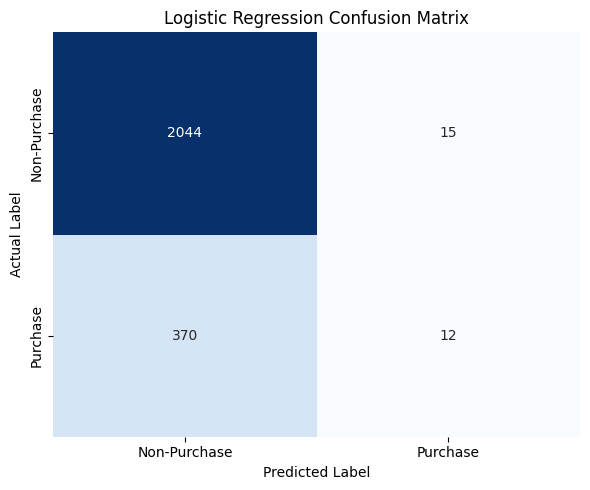

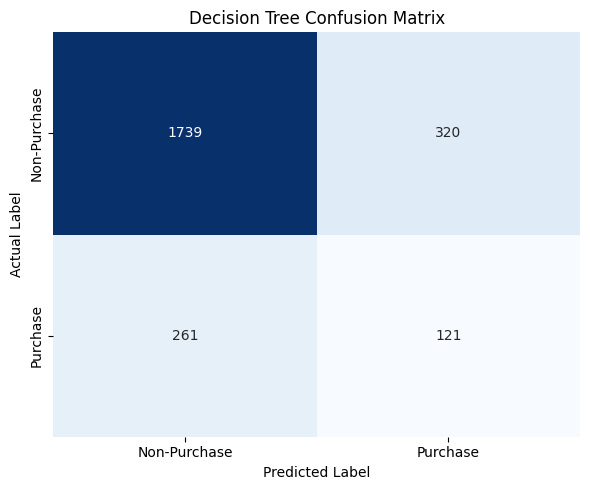

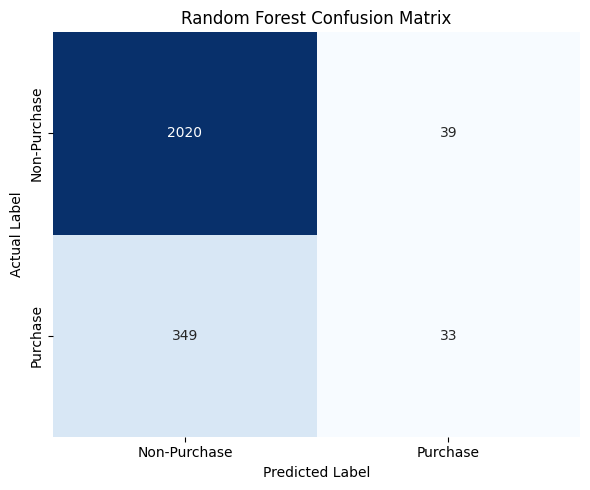

In [183]:
# visualize confusion matrices for all three models side by side
confusion_matrices = [
    ("Logistic Regression", logistic_confusion),
    ("Decision Tree", tree_confusion),
    ("Random Forest", forest_confusion),
]

# define class labels for the confusion matrix axes
class_labels = ["Non-Purchase", "Purchase"]

# create a heatmap for each confusion matrix with appropriate titles and axis labels
for title, matrix in confusion_matrices:
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
    )
    plt.title(f"{title} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

##### Step 6a - Decision Tree Diagram

A decision tree diagram a useful visualization because as it shows how the model splits sessions into purchase and non purchase groups. To keep the diagram readable, we'll show only the top levels of the fitted tree - they highlight the most important decision rules.

It is also interesting that the tree uses `ExitRates` as its first split even though that feature was removed from logistic regression. We should not interpret this to mean `ExitRates` lacked predictive value.  Rather, it was removed from logistic regression because it was highly collinear with other session behavior features. Collinearity makes a linear model less stable and harder to interpret. 

Interestingly, tree based models are less sensitive to that issue, and the decision tree can still use `ExitRates` as the strongest threshold for separating purchase from non purchase sessions.

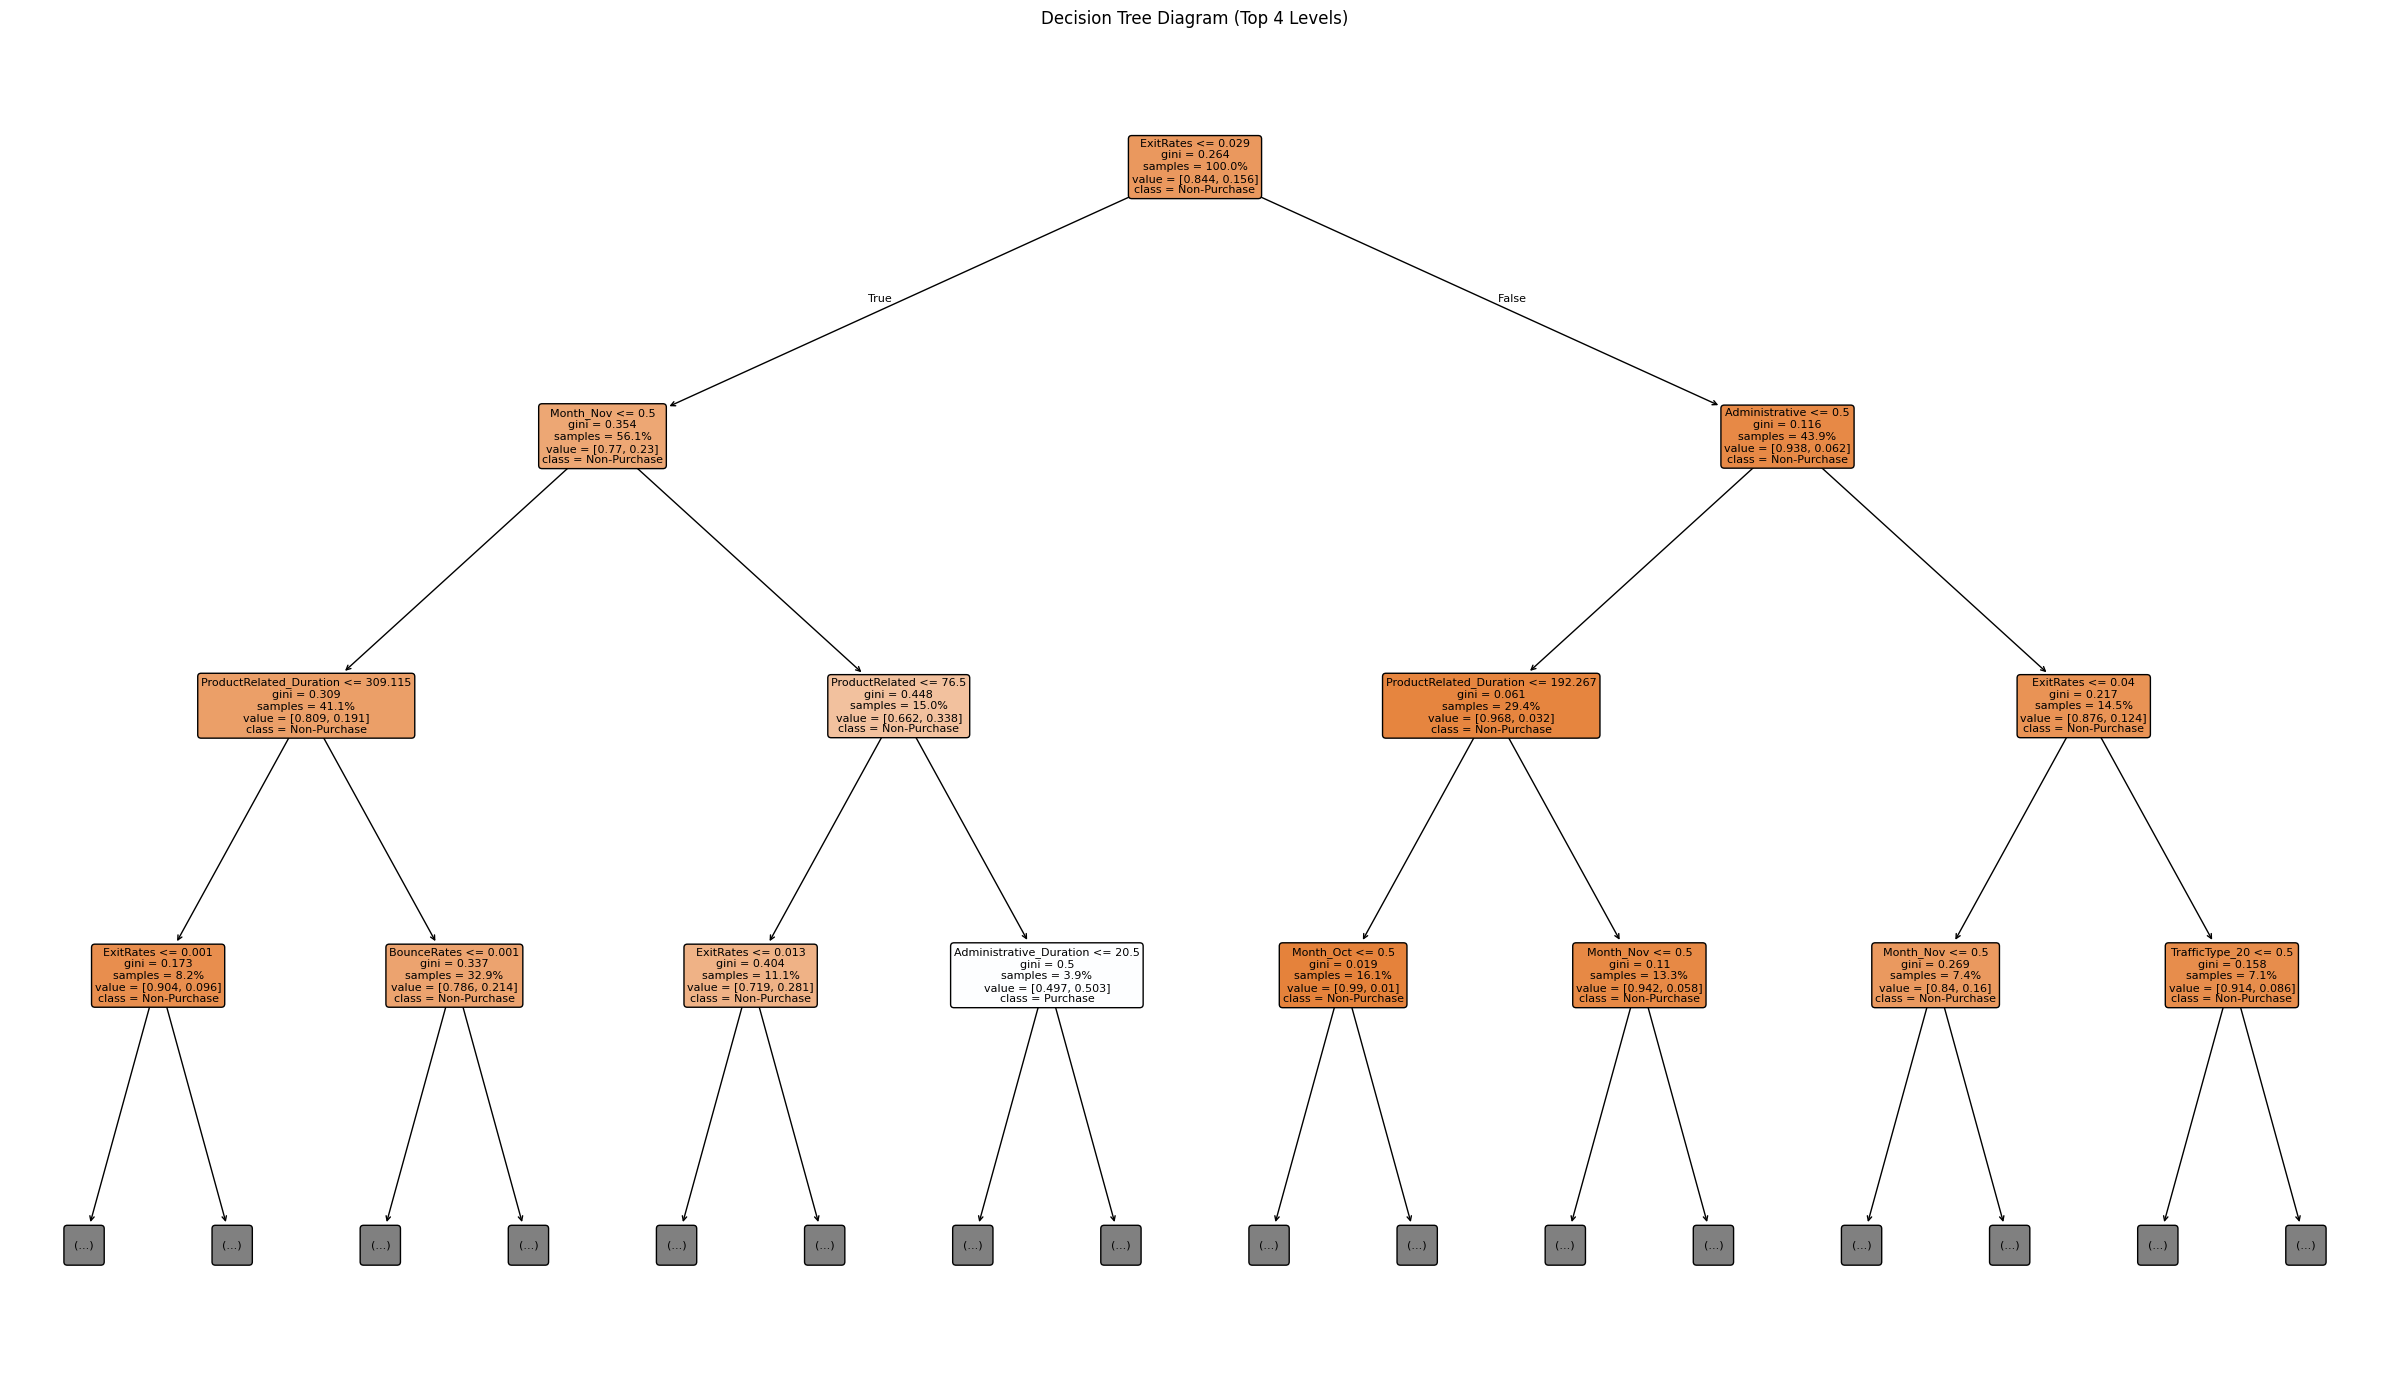

In [ ]:

# visualize the decision tree structure for the trained decision tree model using the full encoded feature set
plt.figure(figsize=(24, 14))

# plot the tree with feature names, class names, and additional formatting for readability
plot_tree(
    tree_model,
    feature_names=X_tree_train.columns,
    class_names=["Non-Purchase", "Purchase"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
    impurity=True,
    proportion=True,
 )

# add title and adjust layout for better display of the tree diagram
plt.title("Decision Tree Diagram (Top 4 Levels)")
plt.tight_layout()
plt.show()

##### Step 6b - ROC-AUC

On first viewing the ROC-AUC results they appear to contradict the confusion matrices.  However, this is not the case as they measure different things. ROC-AUC evaluates how well each model separates purchasers from non purchasers across all possible thresholds, while the confusion matrix evaluates performance at one fixed classification threshold.

This difference means the random forest can show stronger overall class discrimination even though the decision tree still captures more actual purchasers. That is why the decision tree remained stronger on purchase recall and F1-score, while the random forest produced the best overall ROC-AUC.

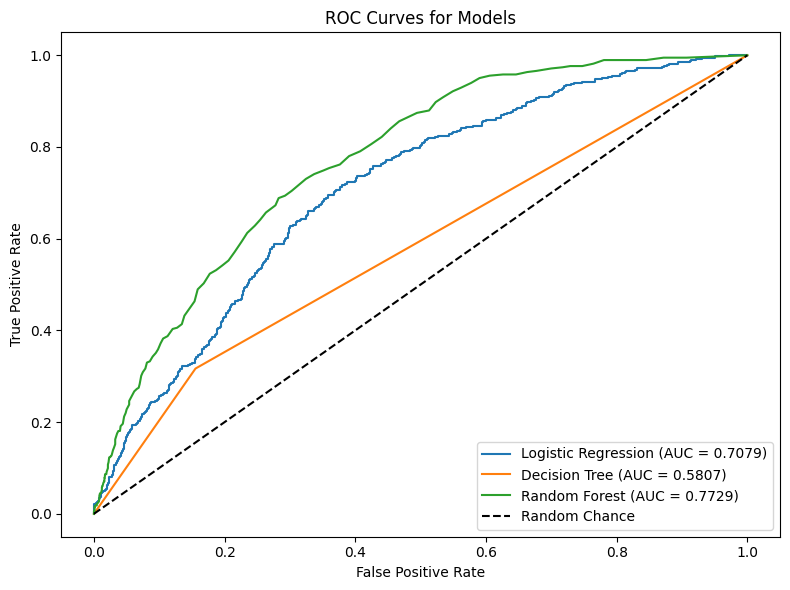

In [ ]:
# do roc auc analysis for all three models
from sklearn.metrics import roc_curve, auc

# define the models and their corresponding test feature sets for ROC curve analysis
models = [
    ("Logistic Regression", logistic_model, X_logistic_test),
    ("Decision Tree", tree_model, X_tree_test),
    ("Random Forest", forest_model, X_tree_test),
]

# create a single plot to compare the ROC curves of all three models with appropriate labels, title, and legend
plt.figure(figsize=(8, 6))
for model_name, model, X_test in models:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")

# add a dashed diagonal line to represent random chance and set plot limits, labels, title, and legend
plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
plt.title("ROC Curves for Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

##### Step 7 - Comparison With Leakage Feature: PageValues

We'll rerun the classification summaries with `PageValues` in the feature set.

We can see that by keeping `PageValues` in the data improved all three models, which is a strong sign that the feature leaks information about the target rather than simply adding normal predictive signal.

For logistic regression, the change was dramatic: accuracy rose from 84.2% to 89.0%, and the purchase class F1-score jumped from  0.06 to 0.53. The model became much better at identifying purchases once `PageValues` was available.

The decision tree also improved. Its accuracy increased from 76.2% to 86.0%, and its purchase class F1-score rose from 0.29 to 0.56, this shows that the added feature made purchase and non purchase sessions much easier to separate.

The random forest saw the strongest overall result with `PageValues` included. Accuracy increased from 84.1% to 90.0%, and the purchase class F1-score improved from 0.15 to 0.65. This large jump reinforces why `PageValues` was removed from the main analysis: it makes the models look much stronger, but the comparison is no longer realistic because the feature is too closely tied to conversion itself.

In [ ]:
# Refit the three model families with PageValues included.
# Treat these results as a leakage check rather than a fair comparison to the earlier models.
from sklearn.ensemble import RandomForestClassifier

# make a working copy and convert boolean style values into numeric form to match the other columns and make it easier to work with
pagevalues_df = df.copy()
pagevalues_df["Weekend"] = pagevalues_df["Weekend"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})
pagevalues_df["Revenue"] = pagevalues_df["Revenue"].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})
pagevalues_df = pagevalues_df.drop_duplicates().reset_index(drop=True)

# one hot encode categorical columns including PageValues since it's a numeric column and not a categorical feature
pagevalues_encoded = pd.get_dummies(
    pagevalues_df,
    columns=categorical_features,
    drop_first=True,
    dtype=int,
)

# prepare feature sets and target variable for modeling with PageValues included
pagevalues_target = pagevalues_encoded[target].copy()
pagevalues_tree = pagevalues_encoded.drop(columns=[target]).copy()
pagevalues_logistic = pagevalues_tree.copy()

# identify which numeric features to scale for logistic regression including PageValues
pagevalues_numeric_features = numeric_features + ["PageValues"]
pagevalues_logistic[pagevalues_numeric_features] = StandardScaler().fit_transform(
    pagevalues_logistic[pagevalues_numeric_features]
 )

# check VIF scores with PageValues included to see if it causes any additional multicollinearity issues for logistic regression
pagevalues_vif_input = pagevalues_logistic.astype(float).copy()
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="divide by zero encountered in scalar divide",
        category=RuntimeWarning,
    )
    # calculate VIF for each feature and store results in a DataFrame
    pagevalues_vif_scores = pd.DataFrame(
        {
            "feature": pagevalues_vif_input.columns,
            "VIF": [
                variance_inflation_factor(pagevalues_vif_input.values, index)
                for index in range(pagevalues_vif_input.shape[1])
            ],
        }
    )

# identify features with VIF above the threshold or infinite VIF to drop from logistic regression when PageValues is included
pagevalues_features_to_drop = pagevalues_vif_scores.loc[
    (pagevalues_vif_scores["VIF"] >= vif_threshold)
    | np.isinf(pagevalues_vif_scores["VIF"]),
    "feature",
] .tolist()

# prepare final feature sets for modeling with PageValues included after dropping high VIF features from logistic regression
pagevalues_logistic = pagevalues_encoded.drop(
    columns=[target] + pagevalues_features_to_drop,
    errors="ignore",
).copy()

# identify which numeric features remain after the VIF-based drop to re-scale only those for logistic regression when PageValues is included
pagevalues_remaining_numeric = [
    feature for feature in pagevalues_numeric_features if feature in pagevalues_logistic.columns
]

# re-scale the remaining numeric features for logistic regression after the VIF-based drop when PageValues is included
pagevalues_logistic[pagevalues_remaining_numeric] = StandardScaler().fit_transform(
    pagevalues_logistic[pagevalues_remaining_numeric]
 )

# use stratified sampling to ensure the same class balance in train and test sets since the target is imbalanced
(
    pagevalues_logistic_train,
    pagevalues_logistic_test,
    pagevalues_tree_train,
    pagevalues_tree_test,
    pagevalues_y_train,
    pagevalues_y_test,
 ) = train_test_split(
    pagevalues_logistic,
    pagevalues_tree,
    pagevalues_target,
    test_size=0.20,
    random_state=42,
    stratify=pagevalues_target,
)

# train and evaluate the logistic regression, with PageValues included to check for leakage effects
pagevalues_logistic_model = LogisticRegression(max_iter=1000, random_state=42)
# fit the logistic regression model on the training data and predict on the test data with PageValues included
pagevalues_logistic_model.fit(pagevalues_logistic_train, pagevalues_y_train)
pagevalues_logistic_pred = pagevalues_logistic_model.predict(pagevalues_logistic_test)

# train and evaluate the decision tree model with PageValues included
pagevalues_tree_model = DecisionTreeClassifier(random_state=42)
# fit the decision tree model on the training data and predict on the test data with PageValues included
pagevalues_tree_model.fit(pagevalues_tree_train, pagevalues_y_train)
pagevalues_tree_pred = pagevalues_tree_model.predict(pagevalues_tree_test)

# train and evaluate the random forest model with PageValues included
pagevalues_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

# fit the random forest model on the training data and predict on the test data with PageValues included
pagevalues_forest_model.fit(pagevalues_tree_train, pagevalues_y_train)
pagevalues_forest_pred = pagevalues_forest_model.predict(pagevalues_tree_test)

print("Logistic Regression With PageValues")
print(classification_report(pagevalues_y_test, pagevalues_logistic_pred))
print("Decision Tree With PageValues")
print(classification_report(pagevalues_y_test, pagevalues_tree_pred))
print("Random Forest With PageValues")
print(classification_report(pagevalues_y_test, pagevalues_forest_pred))

print("Features dropped from logistic regression in the PageValues run:")
print(pagevalues_features_to_drop)

Logistic Regression With PageValues
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      2059
           1       0.74      0.41      0.53       382

    accuracy                           0.89      2441
   macro avg       0.82      0.69      0.73      2441
weighted avg       0.87      0.89      0.87      2441

Decision Tree With PageValues
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      2059
           1       0.55      0.57      0.56       382

    accuracy                           0.86      2441
   macro avg       0.73      0.74      0.74      2441
weighted avg       0.86      0.86      0.86      2441

Random Forest With PageValues
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2059
           1       0.76      0.56      0.65       382

    accuracy                           0.90      2441
   macro avg       0.84      0.7

##### Step 8 - Conclusion

**Model Strengths and Weaknesses**

- Logistic Regression: Its main strength was strong overall accuracy and a simple, interpretable structure, but it was too conservative for this problem and missed most actual purchasers. This made it a useful baseline model, but not the best choice for identifying the minority purchase class.

- Decision Tree: Its main strength was the best recall and F1-score for the purchase class, along with a structure that was easy to interpret visually. Its weakness was lower overall accuracy and a greater tendency to produce false positives, but for this project that tradeoff was acceptable because detecting purchasers was the more important goal.

- Random Forest: Its main strength was the best overall class discrimination in the ROC-AUC analysis and strong overall accuracy, showing that it separated the classes well across thresholds. Its weakness was that at the default classification cutoff it remained more conservative than the decision tree, so it did not capture as many true purchasers even though it was the strongest ranking model overall.

**Final Summary**

Across the three main models, the decision tree was the most useful model choice because it preformed well identifying actual purchase sessions. Even though its overall accuracy was lower than logistic regression and random forest, it produced the strongest purchase class recall and F1-score.  These matters the most in animbalanced dataset, such as this one, because the goal is not just to predict the majority non purchase class, but to detect the smaller group of sessions that are likely to convert - after all that is the main intent of this model.

The decision tree also provided a clear interpretation advantage. Its split diagram showed how browsing behavior variables such as `ExitRates` and page activity measures were used to separate purchase from non purchase sessions. That visual separation made the model easier to explain in business terms vs the logistic regression or the random forest models.

For all 3 models, there was only light tuning applied. Logistic regression was given a higher iteration limit to ensure coefficient stability. The decision tree was left at the default settings. The random forest used 200 trees to create a more stable model.

The limited tuning was reasonable because the goal was to compare model behavior and interpretability rather than fully optimize predictive performance. This makes the conclusion about the decision tree strong, as it was the most predictive model under the more simple and consistent model setup.

Leaving out `PageValues` was also the right decision. When `PageValues` was added in, all three models improved greatly, but the results we saw are not realistic for the true prediction problem as the feature is so closely tied to actual conversions. The objective is to predict whether a purchase will happen before it happens, the models without `PageValues` provide the more honest and useful evaluation of performance, albeit lower overall scores.

From an actionable perspective, the notebook points to a consistent pattern: sessions with stronger exit and bounce behavior were less likely to convert, while stronger product engagement was associated with purchase behavior.
Those are 2 actionable insights that the e-commerce team can use to guide consumers into the funnels that generally lead to higher conversions.

Finding meaningful actions to take is another reason why the decision tree model works well for this classification problem.  It has a two fold approach: it predicts purchases well, and it highlights which parts of the user journey are related to lost conversion and which parts are related to actual conversion.  Overall, a very powerful tool.


